# Task 5 — Entity Class Honest ASR & Collapse Curve

**Purpose:** Characterize how honest ASR and retrieval rate collapse as within-class
query similarity decreases from paraphrase (~0.90) to entity (~0.56).

**Data sources:**
- `step0_paraphrase_rejudged_retrieval.csv` — Shafran arm, 20 paraphrase classes (Step 0)
- `task5_entity_singlequery_honest.csv` — Shafran arm, entity classes (Task 5)

**Key question:** Is the ASR collapse driven by retrieval failure, jamming failure, or both?

In [1]:
import csv
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

RESULTS = Path('/home/ishana/scratch/results')
FIGS    = Path('/home/ishana/scratch/results')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Load and prepare data

In [2]:
# ── Paraphrase data (Step 0, Shafran arm only) ────────────────────────────────
para_rows = []
with open(RESULTS / 'step0_paraphrase_rejudged_retrieval.csv') as f:
    for row in csv.DictReader(f):
        if row['variant'] == 'shafran':
            para_rows.append(row)

# Load paraphrase within-class similarities
with open('/home/ishana/scratch/data/classes/paraphrase_classes.json') as f:
    para_classes_json = json.load(f)
para_embs = np.load('/home/ishana/scratch/data/classes/paraphrase_embeddings.npy')

para_sim_map: dict[str, float] = {}
for i, cls in enumerate(para_classes_json):
    queries = [cls['original_query']] + cls['paraphrases']
    n = len(queries)
    e = para_embs[i, :n]
    norms = np.linalg.norm(e, axis=1, keepdims=True)
    e_norm = e / np.where(norms < 1e-9, 1.0, norms)
    pw = e_norm @ e_norm.T
    pairs = [pw[r, c] for r in range(n) for c in range(r+1, n)]
    cid = cls.get('class_id', f'para_{i:03d}')
    # Map to test class IDs used in step0
    # The step0 CSV uses class_ids from the first 20 classes
    para_sim_map[cid] = float(np.mean(pairs))

# Aggregate paraphrase per class
para_pc: dict[str, dict] = defaultdict(lambda: {'ret': 0, 'jam': 0, 'n': 0, 'sim': 0.0})
for r in para_rows:
    cid = r['class_id']
    para_pc[cid]['ret'] += int(r['retrieved_top5'])
    para_pc[cid]['jam'] += int(r['jammed_honest'])
    para_pc[cid]['n']   += 1

# Assign within-class sim (use pre-computed values)
# Re-compute directly from the embedding file aligned to test class IDs
test_class_ids = sorted(para_pc.keys())
print(f'Paraphrase classes: {len(test_class_ids)}')
print(f'Para class IDs: {test_class_ids[:5]}')

Paraphrase classes: 20
Para class IDs: ['test1', 'test10', 'test11', 'test12', 'test13']


In [3]:
# Map test1...test32 → class index in JSON
# The eval_m2_paraphrase.py used load_paraphrase_classes() which iterates classes[:20]
# and assigns class_id = cls.setdefault('class_id', f'para_{i:03d}') — but the JSON
# already has class_id fields starting with 'test'
with open('/home/ishana/scratch/data/classes/paraphrase_classes.json') as f:
    para_json = json.load(f)

# Build sim map by class_id
para_sim_by_cid: dict[str, float] = {}
for i, cls in enumerate(para_json[:20]):
    cid = cls.get('class_id', f'para_{i:03d}')
    n_q = len([cls['original_query']] + cls['paraphrases'])
    e = para_embs[i, :n_q]
    norms = np.linalg.norm(e, axis=1, keepdims=True)
    e_norm = e / np.where(norms < 1e-9, 1.0, norms)
    pw = e_norm @ e_norm.T
    pairs = [pw[r, c] for r in range(n_q) for c in range(r+1, n_q)]
    para_sim_by_cid[cid] = float(np.mean(pairs)) if pairs else 0.0

for cid, pc in para_pc.items():
    pc['sim'] = para_sim_by_cid.get(cid, 0.902)  # fallback to global mean

print('Paraphrase sim range:', min(v['sim'] for v in para_pc.values()), 
      '–', max(v['sim'] for v in para_pc.values()))

Paraphrase sim range: 0.8535205125808716 – 0.9725362658500671


In [4]:
# ── Entity data (Task 5) ──────────────────────────────────────────────────────
entity_csv = RESULTS / 'task5_entity_singlequery_honest.csv'
assert entity_csv.exists(), f'Run eval_task5_entity_singlequery.py first: {entity_csv}'

entity_rows = []
with open(entity_csv) as f:
    for row in csv.DictReader(f):
        entity_rows.append(row)

entity_pc: dict[str, dict] = defaultdict(lambda: {'ret': 0, 'jam': 0, 'n': 0, 'sim': 0.0})
for r in entity_rows:
    cid = r['class_id']
    entity_pc[cid]['ret'] += int(r['retrieved_top5'])
    entity_pc[cid]['jam'] += int(r['jammed_honest'])
    entity_pc[cid]['n']   += 1
    entity_pc[cid]['sim']  = float(r['within_class_sim'])

print(f'Entity classes: {len(entity_pc)}')
print(f'Entity sim range: {min(v["sim"] for v in entity_pc.values()):.3f} – '
      f'{max(v["sim"] for v in entity_pc.values()):.3f}')

Entity classes: 6
Entity sim range: 0.476 – 0.630


In [5]:
# ── Build combined per-class dataframe ───────────────────────────────────────
records = []

for cid, pc in para_pc.items():
    n = pc['n']
    records.append({
        'class_id':   cid,
        'class_type': 'paraphrase',
        'sim':        pc['sim'],
        'n_queries':  n,
        'ret_rate':   pc['ret'] / n,
        'asr_honest': pc['jam'] / n,
        'n_ret':      pc['ret'],
        'n_jam':      pc['jam'],
        'p_jam_given_ret': pc['jam'] / pc['ret'] if pc['ret'] > 0 else float('nan'),
    })

for cid, pc in entity_pc.items():
    n = pc['n']
    records.append({
        'class_id':   cid,
        'class_type': 'entity',
        'sim':        pc['sim'],
        'n_queries':  n,
        'ret_rate':   pc['ret'] / n,
        'asr_honest': pc['jam'] / n,
        'n_ret':      pc['ret'],
        'n_jam':      pc['jam'],
        'p_jam_given_ret': pc['jam'] / pc['ret'] if pc['ret'] > 0 else float('nan'),
    })

df = pd.DataFrame(records).sort_values('sim').reset_index(drop=True)
print(df[['class_id', 'class_type', 'sim', 'ret_rate', 'asr_honest', 'p_jam_given_ret']]
      .to_string(index=False, float_format='{:.3f}'.format))

 class_id class_type   sim  ret_rate  asr_honest  p_jam_given_ret
entity_18     entity 0.476     0.333       0.333            1.000
entity_07     entity 0.478     0.167       0.167            1.000
entity_12     entity 0.502     0.250       0.000            0.000
entity_00     entity 0.529     0.125       0.125            1.000
entity_08     entity 0.614     0.000       0.000              NaN
entity_03     entity 0.630     0.000       0.000              NaN
   test20 paraphrase 0.854     0.167       0.000            0.000
   test22 paraphrase 0.855     0.667       0.333            0.500
    test9 paraphrase 0.871     1.000       1.000            1.000
   test13 paraphrase 0.877     0.000       0.000              NaN
   test12 paraphrase 0.882     0.000       0.000              NaN
   test21 paraphrase 0.889     1.000       0.667            0.667
    test6 paraphrase 0.892     0.833       0.833            1.000
   test16 paraphrase 0.894     0.000       0.000              NaN
   test14 

## 2. Summary statistics

In [6]:
for ct in ['paraphrase', 'entity']:
    sub = df[df.class_type == ct]
    total_n   = sub.n_queries.sum()
    total_ret = sub.n_ret.sum()
    total_jam = sub.n_jam.sum()
    print(f'=== {ct.upper()} ===')
    print(f'  Classes:        {len(sub)}')
    print(f'  Mean sim:       {sub.sim.mean():.3f}  [{sub.sim.min():.3f}–{sub.sim.max():.3f}]')
    print(f'  Retrieval rate: {total_ret}/{total_n} = {100*total_ret/total_n:.1f}%')
    print(f'  Honest ASR:     {total_jam}/{total_n} = {100*total_jam/total_n:.1f}%')
    ret_rows  = sub[sub.n_ret > 0]
    if not ret_rows.empty:
        # Aggregate P(jam|retrieved)
        agg_jam_given_ret = sub.n_jam.sum() / sub.n_ret.sum() if sub.n_ret.sum() > 0 else float('nan')
        print(f'  P(jam|retrieved): {agg_jam_given_ret:.3f}')
    print()

=== PARAPHRASE ===
  Classes:        20
  Mean sim:       0.902  [0.854–0.973]
  Retrieval rate: 61/120 = 50.8%
  Honest ASR:     46/120 = 38.3%
  P(jam|retrieved): 0.754

=== ENTITY ===
  Classes:        6
  Mean sim:       0.538  [0.476–0.630]
  Retrieval rate: 4/34 = 11.8%
  Honest ASR:     3/34 = 8.8%
  P(jam|retrieved): 0.750



## 3. Key Figure: Honest ASR + Retrieval Rate vs Within-Class Similarity

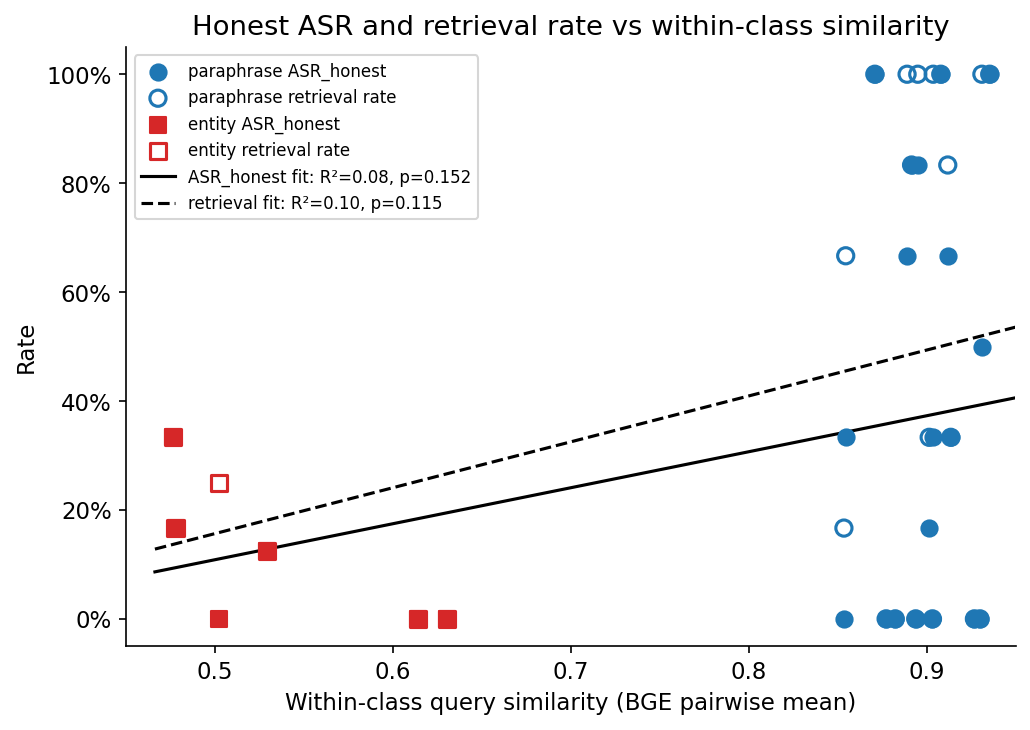

Saved task5_collapse_curve.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = {'paraphrase': '#1f77b4', 'entity': '#d62728'}
markers = {'paraphrase': 'o', 'entity': 's'}

# Scatter: honest ASR (filled) and retrieval rate (open) per class
for ct in ['paraphrase', 'entity']:
    sub = df[df.class_type == ct]
    c   = colors[ct]
    mk  = markers[ct]
    ax.scatter(sub.sim, sub.asr_honest,  color=c, marker=mk,  s=60,
               label=f'{ct} ASR_honest', zorder=4)
    ax.scatter(sub.sim, sub.ret_rate,    color=c, marker=mk,  s=60,
               facecolors='none', linewidths=1.5,
               label=f'{ct} retrieval rate', zorder=3)

# Regression lines for ASR_honest across all classes
x = df.sim.values
y_asr = df.asr_honest.values
y_ret = df.ret_rate.values

for y, lbl, ls in [(y_asr, 'ASR_honest fit', '-'), (y_ret, 'retrieval fit', '--')]:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min() - 0.01, x.max() + 0.01, 100)
    y_line = slope * x_line + intercept
    r2 = r**2
    ax.plot(x_line, y_line, color='k', ls=ls, lw=1.5,
            label=f'{lbl}: R²={r2:.2f}, p={p:.3f}')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Within-class query similarity (BGE pairwise mean)')
ax.set_ylabel('Rate')
ax.set_title('Honest ASR and retrieval rate vs within-class similarity')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0.45, 0.95)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
fig.savefig(FIGS / 'task5_collapse_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved task5_collapse_curve.png')

## 4. Decomposition: retrieval failure vs jamming failure

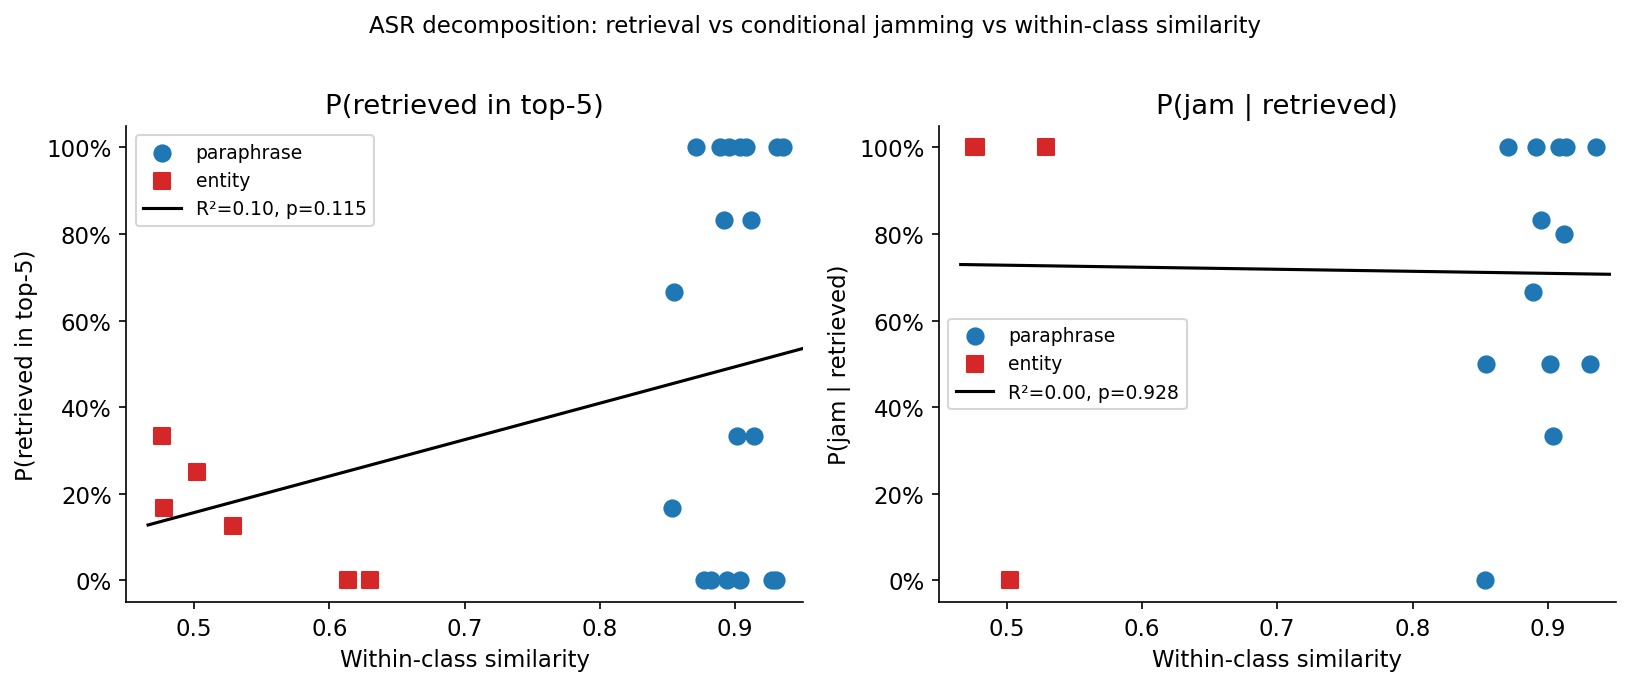

Saved task5_decomposition.png


In [8]:
# ASR_honest = P(retrieved) × P(jam|retrieved)
# Collapse can come from P(retrieved) drop, P(jam|retrieved) drop, or both.

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (y_col, y_lbl) in zip(axes, [
    ('ret_rate',        'P(retrieved in top-5)'),
    ('p_jam_given_ret', 'P(jam | retrieved)'),
]):
    for ct in ['paraphrase', 'entity']:
        sub = df[df.class_type == ct].dropna(subset=[y_col])
        c   = colors[ct]
        mk  = markers[ct]
        ax.scatter(sub.sim, sub[y_col], color=c, marker=mk, s=60,
                   label=ct, zorder=4)

    # Regression across all classes
    sub_all = df.dropna(subset=[y_col])
    x  = sub_all.sim.values
    y  = sub_all[y_col].values
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min()-0.01, x.max()+0.01, 100)
    ax.plot(x_line, slope*x_line+intercept, 'k-', lw=1.5,
            label=f'R²={r**2:.2f}, p={p:.3f}')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel('Within-class similarity')
    ax.set_ylabel(y_lbl)
    ax.set_title(y_lbl)
    ax.legend(fontsize=9)
    ax.set_xlim(0.45, 0.95)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('ASR decomposition: retrieval vs conditional jamming vs within-class similarity',
             fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(FIGS / 'task5_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved task5_decomposition.png')

## 5. Regression summary table

In [9]:
print(f'{'Outcome':<28} {'slope':>8} {'intercept':>10} {'R²':>6} {'p':>8}')
print('-' * 66)
for y_col, y_lbl in [
    ('asr_honest',       'Honest ASR'),
    ('ret_rate',         'Retrieval rate'),
    ('p_jam_given_ret',  'P(jam|retrieved)'),
]:
    sub = df.dropna(subset=[y_col])
    x = sub.sim.values
    y = sub[y_col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    print(f'{y_lbl:<28} {slope:>8.3f} {intercept:>10.3f} {r**2:>6.3f} {p:>8.4f}')

Outcome                         slope  intercept     R²        p
------------------------------------------------------------------
Honest ASR                      0.661     -0.222  0.084   0.1522
Retrieval rate                  0.842     -0.264  0.100   0.1154
P(jam|retrieved)               -0.047      0.751  0.001   0.9284


## 6. Per-class breakdown table

In [10]:
display_df = df[[
    'class_id', 'class_type', 'sim', 'n_queries',
    'ret_rate', 'asr_honest', 'p_jam_given_ret'
]].copy()
display_df['ret_%']  = (display_df.ret_rate * 100).round(0).astype(int)
display_df['asr_%']  = (display_df.asr_honest * 100).round(0).astype(int)
display_df['p_j_r%'] = (display_df.p_jam_given_ret * 100).round(0)

print(display_df[[
    'class_id', 'class_type', 'sim', 'n_queries', 'ret_%', 'asr_%', 'p_j_r%'
]].to_string(index=False))

 class_id class_type      sim  n_queries  ret_%  asr_%  p_j_r%
entity_18     entity 0.476100          3     33     33   100.0
entity_07     entity 0.477700          6     17     17   100.0
entity_12     entity 0.502200          4     25      0     0.0
entity_00     entity 0.528900          8     12     12   100.0
entity_08     entity 0.613800          6      0      0     NaN
entity_03     entity 0.630400          7      0      0     NaN
   test20 paraphrase 0.853521          6     17      0     0.0
   test22 paraphrase 0.854524          6     67     33    50.0
    test9 paraphrase 0.870897          6    100    100   100.0
   test13 paraphrase 0.877246          6      0      0     NaN
   test12 paraphrase 0.882390          6      0      0     NaN
   test21 paraphrase 0.889035          6    100     67    67.0
    test6 paraphrase 0.891567          6     83     83   100.0
   test16 paraphrase 0.893882          6      0      0     NaN
   test14 paraphrase 0.895048          6    100     83 

In [11]:
# Global summary across both class types
print('=== GLOBAL SUMMARY (paraphrase + entity) ===')
for ct in ['paraphrase', 'entity', 'all']:
    sub = df if ct == 'all' else df[df.class_type == ct]
    n = sub.n_queries.sum()
    r = sub.n_ret.sum()
    j = sub.n_jam.sum()
    agg_jgr = j / r if r > 0 else float('nan')
    print(f'  {ct:<12}: retrieval={100*r/n:.1f}%  '
          f'asr_honest={100*j/n:.1f}%  '
          f'P(jam|ret)={100*agg_jgr:.1f}%')

=== GLOBAL SUMMARY (paraphrase + entity) ===
  paraphrase  : retrieval=50.8%  asr_honest=38.3%  P(jam|ret)=75.4%
  entity      : retrieval=11.8%  asr_honest=8.8%  P(jam|ret)=75.0%
  all         : retrieval=42.2%  asr_honest=31.8%  P(jam|ret)=75.4%
